# Генерация русской поэзии: обучение Transformer на датасете Ars Poetica

Это вторая часть учебного проекта по сравнению архитектур (LSTM, Transformer, Mamba) для генерации русской поэзии:

Структура полностью аналогична ноутбуку с LSTM: тот же датасет, тот же посимвольный словарь (с ударениями), то же разбиение на train/val, тот же формат сохраняемых артефактов $-$ чтобы дальше можно было сравнить модели.

In [2]:
import os
import json
import math
import random
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from datasets import load_dataset
import warnings

from tqdm.auto import tqdm
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## 1. Загрузка датасета

In [3]:
dataset = load_dataset("inkoziev/ArsPoetica")
print(dataset)

train_data = dataset["train"]
print("Количество стихотворений:", len(train_data))
print("Пример:")
print(train_data[0])


DatasetDict({
    train: Dataset({
        features: ['author', 'title', 'poem_text', 'accentuation'],
        num_rows: 8498
    })
})
Количество стихотворений: 8498
Пример:
{'author': 'Николай Гумилёв', 'title': 'Аннам', 'poem_text': 'Месяц стоит посредине\nДивно-огромного неба,\nВетер в бамбуковой чаще,\nБлагоухающий воздух,\nБлагословенна семья.\n\nСтаршие в роще за чаем,\nПьют и стихи повторяют,\nИз дому слышно гуденье,\nТам занимаются дети,\nНоворождённый кричит.\n\nТот, кто живёт этой жизнью,\nПолное знает блаженство.\nЧто ему деньги и слава,\nЕсли он верит, что детям\nДолжно его пережить?', 'accentuation': 'Ме́сяц стои́т посреди́не\nДи́вно - огро́много не́ба,\nВе́тер в бамбу́ковой ча́ще,\nБла̀гоуха́ющий во́здух,\nБлагослове́нна семья́.\n\nСта́ршие в ро́ще за ча́ем,\nПью́т и стихи́ повторя́ют,\nИ́з дому слы́шно гуде́нье,\nТа́м занима́ются де́ти,\nНо̀ворождё́нный кричи́т.\n\nТо́т, кто живё́т этой жи́знью,\nПо́лное зна́ет блаже́нство.\nЧто́ ему де́ньги и сла́ва,\nЕ́сли он ве́рит, 

## Настройки параметров обучения

In [19]:
SUBSET_SIZE = 8400

MAX_CHARS = 400          # обрезаем очень длинные стихи
BATCH_SIZE = 64
EPOCHS = 80
LR = 1e-3

HIDDEN_DIM = 128        
NUM_HEADS = 4
NUM_LAYERS = 2
FF_DIM = 256           
DROPOUT = 0.1

## Подготовка текста и словаря

In [20]:
PAD, BOS, EOS = "<pad>", "<bos>", "<eos>"
SPECIALS = [PAD, BOS, EOS]

def get_text(example):
    return example["accentuation"][:MAX_CHARS]


all_texts_full = [get_text(ex) for ex in train_data]
chars = sorted(set("".join(all_texts_full)))
vocab = SPECIALS + chars
char2idx = {c: i for i, c in enumerate(vocab)}
idx2char = {i: c for c, i in char2idx.items()}
PAD_IDX, BOS_IDX, EOS_IDX = char2idx[PAD], char2idx[BOS], char2idx[EOS]
VOCAB_SIZE = len(vocab)
print("Размер словаря (символы):", VOCAB_SIZE)

MAX_LEN = MAX_CHARS + 2  

def encode(text):
    return [BOS_IDX] + [char2idx[c] for c in text] + [EOS_IDX]

def decode(ids):
    return "".join(idx2char[i] for i in ids if i not in (PAD_IDX, BOS_IDX, EOS_IDX))


texts_for_training = all_texts_full.copy()
random.shuffle(texts_for_training)
texts_for_training = texts_for_training[:SUBSET_SIZE]


Размер словаря (символы): 94


## Разделение на Train и Val и DataLoader-ы

In [21]:
n_val = max(1, int(0.05 * len(texts_for_training)))
val_texts = texts_for_training[:n_val]
train_texts = texts_for_training[n_val:]
print(f"Train: {len(train_texts)} стихов, Val: {len(val_texts)} стихов")


class PoemDataset(Dataset):
    def __init__(self, texts):
        self.data = [torch.tensor(encode(t), dtype=torch.long) for t in texts]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


def collate(batch):
    batch = pad_sequence(batch, batch_first=True, padding_value=PAD_IDX)
    inputs = batch[:, :-1]
    targets = batch[:, 1:]
    return inputs, targets


train_ds = PoemDataset(train_texts)
val_ds = PoemDataset(val_texts)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
print(f"Батчей: train={len(train_dl)}, val={len(val_dl)}")


Train: 7980 стихов, Val: 420 стихов
Батчей: train=125, val=7


## Модель Transformer


In [28]:
class CharTransformerLM(nn.Module):
    def __init__(self, vocab_size, hidden_dim=128, num_heads=4, num_layers=2, ff_dim=256,
                 dropout=0.1, max_len=512, pad_idx=0):
        super().__init__()
        self.max_len = max_len
        self.embedding = nn.Embedding(vocab_size, hidden_dim, padding_idx=pad_idx)
        self.positional_encoding = nn.Parameter(torch.zeros(1, max_len, hidden_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        seq_len = x.size(1)
        causal_mask = torch.triu(
            torch.full((seq_len, seq_len), float("-inf"), device=x.device), diagonal=1
        )
        emb = self.embedding(x) + self.positional_encoding[:, :seq_len, :]
        out = self.transformer_encoder(emb, mask=causal_mask)
        logits = self.fc_out(out)
        return logits


model = CharTransformerLM(VOCAB_SIZE, hidden_dim=HIDDEN_DIM, num_heads=NUM_HEADS,
                           num_layers=NUM_LAYERS, ff_dim=FF_DIM, dropout=DROPOUT,
                           max_len=MAX_LEN, pad_idx=PAD_IDX).to(device)
n_params = sum(p.numel() for p in model.parameters())
n_params


340574

In [23]:
def run_epoch(model, dataloader, criterion, optimizer=None, clip=1.0, desc="epoch"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_tokens = 0.0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()
    pbar = tqdm(dataloader, desc=desc, leave=False)
    with context:
        for inputs, targets in pbar:
            inputs, targets = inputs.to(device), targets.to(device)
            if is_train:
                optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
                optimizer.step()
            n_tokens = (targets != PAD_IDX).sum().item()
            total_loss += loss.item() * n_tokens
            total_tokens += n_tokens
            pbar.set_postfix(loss=f"{loss.item():.3f}")
    avg_loss = total_loss / max(total_tokens, 1)
    perplexity = math.exp(avg_loss)
    return avg_loss, perplexity


In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = {"train_loss": [], "val_loss": [], "train_ppl": [], "val_ppl": []}
best_val_loss = float("inf")
CKPT_PATH = "best_transformer.pt"

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_ppl = run_epoch(model, train_dl, criterion, optimizer, desc=f"train {epoch}/{EPOCHS}")
    val_loss, val_ppl = run_epoch(model, val_dl, criterion, None, desc=f"val {epoch}/{EPOCHS}")

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_ppl"].append(train_ppl)
    history["val_ppl"].append(val_ppl)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "model_state": model.state_dict(),
            "config": dict(hidden_dim=HIDDEN_DIM, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
                            ff_dim=FF_DIM, dropout=DROPOUT, max_len=MAX_LEN),
            "char2idx": char2idx,
            "idx2char": idx2char,
            "vocab_size": VOCAB_SIZE,
        }, CKPT_PATH)

    dt = time.time() - t0
    print(f"Эпоха {epoch}/{EPOCHS} | train_loss={train_loss:.3f} | " f"val_loss={val_loss:.3f} | {dt:.1f}с")

print(f"Лучший val_loss: {best_val_loss:.3f} (ppl={math.exp(best_val_loss)})")


train 1/80:   0%|          | 0/125 [00:00<?, ?it/s]

val 1/80:   0%|          | 0/7 [00:00<?, ?it/s]

Эпоха 01/80 | train_loss=2.731 | val_loss=2.526 | 570.2с


train 2/80:   0%|          | 0/125 [00:00<?, ?it/s]

val 2/80:   0%|          | 0/7 [00:00<?, ?it/s]

...

val 79/80:   0%|          | 0/7 [00:00<?, ?it/s]

Эпоха 79/80 | train_loss=1.809 | val_loss=1.710 | 394.6с


train 80/80:   0%|          | 0/125 [00:00<?, ?it/s]

val 80/80:   0%|          | 0/7 [00:00<?, ?it/s]

Эпоха 80/80 | train_loss=1.806 | val_loss=1.699 | 398.7с

Лучший val_loss: 1.699 (ppl=5.5)


In [1]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.xlabel("Эпоха")
plt.ylabel("Cross-entropy loss (символьный)")
plt.title("Transformer")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

NameError: name 'plt' is not defined

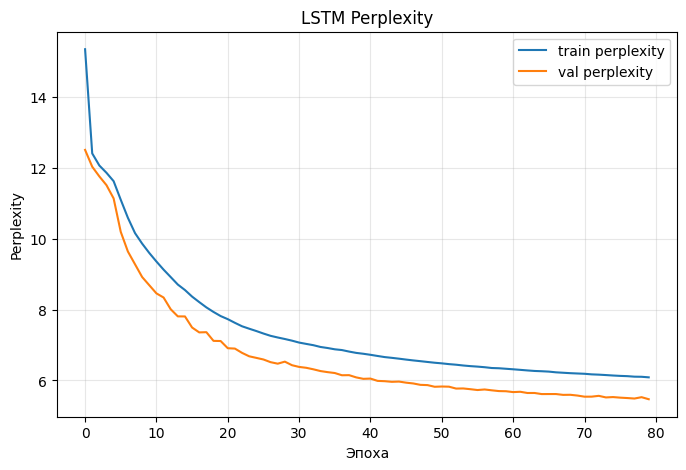

Итоговая perplexity на валидации (последняя эпоха): 5.47
Лучшая perplexity на валидации: 5.47


In [30]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_ppl"], label="train perplexity")
plt.plot(history["val_ppl"], label="val perplexity")

plt.xlabel("Эпоха")
plt.ylabel("Perplexity")
plt.title("LSTM Perplexity")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

print(f"Итоговая perplexity на валидации (последняя эпоха): {history['val_ppl'][-1]:.2f}")
print(f"Лучшая perplexity на валидации: {min(history['val_ppl']):.2f}")


## Генерация текста и нарезка на четверостишия

In [31]:
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model = CharTransformerLM(VOCAB_SIZE, pad_idx=PAD_IDX, **ckpt["config"]).to(device)
model.load_state_dict(ckpt["model_state"])
model.eval()


@torch.no_grad()
def generate_poem(model, max_len=300, temperature=0.8, top_k=30):
    model.eval()
    seq = [BOS_IDX]
    for _ in range(max_len):
        if len(seq) >= MAX_LEN:
            break
        x = torch.tensor([seq], device=device)
        logits = model(x)[0, -1] / temperature
        logits[PAD_IDX] = -float("inf")
        logits[BOS_IDX] = -float("inf")  
        k = min(top_k, logits.size(-1))
        topk_vals, topk_idx = torch.topk(logits, k)
        probs = F.softmax(topk_vals, dim=-1)
        choice = topk_idx[torch.multinomial(probs, 1)].item()
        if choice == EOS_IDX:
            break
        seq.append(choice)
    return "".join(idx2char[i] for i in seq[1:])  


def extract_quatrains(text, n_lines=4):
    lines = [l for l in text.split("\n") if l.strip()]
    quatrains = []
    for i in range(0, len(lines) - n_lines + 1, n_lines):
        chunk = lines[i:i + n_lines]
        if len(chunk) == n_lines:
            quatrains.append("\n".join(chunk))
    return quatrains


In [32]:
N_SAMPLES = 30 

all_quatrains = []
for i in range(N_SAMPLES):
    poem = generate_poem(model)
    qs = extract_quatrains(poem)
    all_quatrains.extend(qs)
    print(f"Сгенерированный стих {i + 1}")
    print(poem)
    print()

print(f"Извлечено четверостиший: {len(all_quatrains)}")


Сгенерированный стих 1
Меня́ молько́ на дого́, и чи́сты не вины́ни.
И о за та́йна зави́нет одну́ю ва́здух не слови́,
Иду́ паса́вляя нока́тность, оди́н, сури́словый ле́ют ла́ге
Но во́лн недви́жных во́здух полна́чет, -
Да ве́и так све́т, чья на́сть дому́ любо́вь и пути́цы,
И по́лнав не гла́дя вы́сь песпи́та и зна́ем,
Вине́е

Сгенерированный стих 2
Для не́жно гла́з и всейчу́ю
И во́лных дру́г душе́.
В сли́зок огро́до зале́нья,
Как бры́вых ча́с, подходи́нский,
Сердце не́ба пред хружа́ биромо́льный -
И де́сь не сла́вом си́ли, слова́.
Пора́сно над се́рдце душа́чью,
Весь гро́мле на во́зовый ру́кой,
Прости́лся мо́й возду́ка.......
Пока́я приле́ская 

Сгенерированный стих 3
Во́т волн сго́рдце томи́ть не на́м?
Вдру́г нежно́ за огнё́т доле́йный,
Ка́к одина́ждая козя́йный в изве́нья
Слу́шая мно́го тве́с тебе́ не стра́стный,
Сла́дость то́лкию свое́й блажё́нной,
чу́ждою забы́ть расе́т трава́ мино́гий
То́ молне́нческой тре́ть сверня́тье
Не хра́м, в мой кры́ть стихочё́ртый
У́

Сгенерированный стих 4
Сл

## визуализация внимания


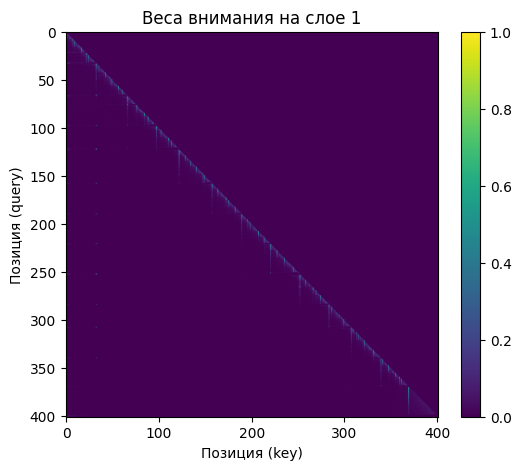

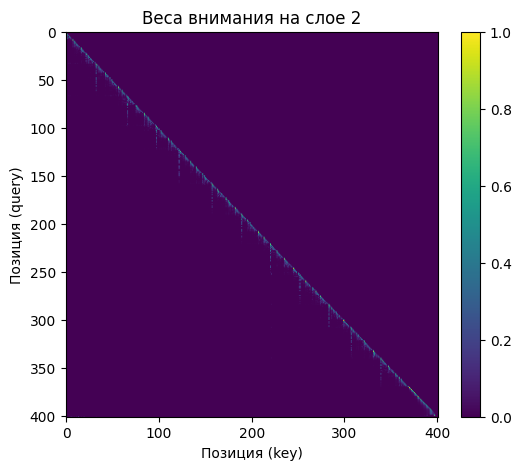

In [33]:
@torch.no_grad()
def get_attention_per_layer(model, x):
    model.eval()
    seq_len = x.size(1)
    mask = torch.triu(torch.full((seq_len, seq_len), float("-inf"), device=x.device), diagonal=1)
    hidden = model.embedding(x) + model.positional_encoding[:, :seq_len, :]
    weights = []
    for layer in model.transformer_encoder.layers:
        _, attn_w = layer.self_attn(hidden, hidden, hidden, attn_mask=mask,
                                     need_weights=True, average_attn_weights=True)
        weights.append(attn_w[0].cpu().numpy())  
        hidden = layer(hidden, src_mask=mask)
    return weights


def plot_attention_weights(weights, layer_idx):
    plt.figure(figsize=(6, 5))
    plt.imshow(weights[layer_idx], cmap="viridis", aspect="auto")
    plt.colorbar()
    plt.title(f"Веса внимания на слое {layer_idx + 1}")
    plt.xlabel("Позиция (key)")
    plt.ylabel("Позиция (query)")
    plt.show()


example_x, _ = next(iter(val_dl))
example_x = example_x[:1].to(device)
attn_weights = get_attention_per_layer(model, example_x)

for layer_idx in range(len(attn_weights)):
    plot_attention_weights(attn_weights, layer_idx)


## Сохранение

In [34]:
with open("vocab.json", "w", encoding="utf-8") as f:
    json.dump({"char2idx": char2idx, "config": ckpt["config"],}, f, ensure_ascii=False, indent=2)

with open("generated_quatrains_transformer.json", "w", encoding="utf-8") as f:
    json.dump(all_quatrains, f, ensure_ascii=False, indent=2)
